In [1]:
import pandas as pd
import numpy as np
import re
import nltk

from nltk.corpus import stopwords
from nltk.stem import PorterStemmer

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [2]:
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Tharun\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.


True

In [11]:
import pandas as pd

df = pd.read_csv(
    r"C:\Users\Tharun\Downloads\training.1600000.processed.noemoticon.csv\training.1600000.processed.noemoticon.csv",
    encoding="latin-1",
    header=None
)

print(df.head())
print(df.shape)

   0           1                             2         3                4  \
0  0  1467810369  Mon Apr 06 22:19:45 PDT 2009  NO_QUERY  _TheSpecialOne_   
1  0  1467810672  Mon Apr 06 22:19:49 PDT 2009  NO_QUERY    scotthamilton   
2  0  1467810917  Mon Apr 06 22:19:53 PDT 2009  NO_QUERY         mattycus   
3  0  1467811184  Mon Apr 06 22:19:57 PDT 2009  NO_QUERY          ElleCTF   
4  0  1467811193  Mon Apr 06 22:19:57 PDT 2009  NO_QUERY           Karoli   

                                                   5  
0  @switchfoot http://twitpic.com/2y1zl - Awww, t...  
1  is upset that he can't update his Facebook by ...  
2  @Kenichan I dived many times for the ball. Man...  
3    my whole body feels itchy and like its on fire   
4  @nationwideclass no, it's not behaving at all....  
(1600000, 6)


In [12]:
stemmer = PorterStemmer()

def clean_text(text):
    
    text = re.sub(r"http\S+", "", str(text))
    text = re.sub(r"@\w+", "", text)
    text = re.sub(r"[^a-zA-Z]", " ", text)

    text = text.lower()

    words = text.split()

    words = [
        stemmer.stem(word)
        for word in words
        if word not in stopwords.words("english")
    ]

    return " ".join(words)

In [14]:
print(df.columns)

Index([0, 1, 2, 3, 4, 5], dtype='int64')


In [15]:
df.columns = [
    "sentiment",
    "id",
    "date",
    "query",
    "user",
    "tweet"
]

print(df.columns)

Index(['sentiment', 'id', 'date', 'query', 'user', 'tweet'], dtype='object')


In [17]:
print(df["tweet"].head())

0    @switchfoot http://twitpic.com/2y1zl - Awww, t...
1    is upset that he can't update his Facebook by ...
2    @Kenichan I dived many times for the ball. Man...
3      my whole body feels itchy and like its on fire 
4    @nationwideclass no, it's not behaving at all....
Name: tweet, dtype: object


In [19]:
df = df.sample(50000, random_state=42)

print(df.shape)

(50000, 6)


In [21]:
import re
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer

stop_words = set(stopwords.words("english"))
stemmer = PorterStemmer()

def clean_text(text):

    text = re.sub(r"http\S+", "", str(text))
    text = re.sub(r"@\w+", "", text)
    text = re.sub(r"[^a-zA-Z]", " ", text)

    text = text.lower()

    words = text.split()

    words = [
        stemmer.stem(word)
        for word in words
        if word not in stop_words
    ]

    return " ".join(words)

In [22]:
print(clean_text(df["tweet"].iloc[0]))

ahhh hope ok


In [23]:
df["clean_tweet"] = df["tweet"].apply(clean_text)

In [24]:
print(df[["tweet","clean_tweet"]].head())

                                                    tweet  \
541200             @chrishasboobs AHHH I HOPE YOUR OK!!!    
750     @misstoriblack cool , i have no tweet apps  fo...   
766711  @TiannaChaos i know  just family drama. its la...   
285055  School email won't open  and I have geography ...   
705995                             upper airways problem    

                                              clean_tweet  
541200                                       ahhh hope ok  
750                                   cool tweet app razr  
766711  know famili drama lame hey next time u hang ki...  
285055  school email open geographi stuff revis stupid...  
705995                               upper airway problem  


In [25]:
vectorizer = TfidfVectorizer(max_features=5000)

X = vectorizer.fit_transform(df["clean_tweet"])

y = df["sentiment"]

In [26]:
print(df.columns)

Index(['sentiment', 'id', 'date', 'query', 'user', 'tweet', 'clean_tweet'], dtype='object')


In [27]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(max_features=5000)

X = vectorizer.fit_transform(df["clean_tweet"])

y = df["sentiment"]

print(X.shape)

(50000, 5000)


In [28]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(40000, 5000)
(10000, 5000)


In [29]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [30]:
predictions = model.predict(X_test)

In [31]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, predictions)

print("Accuracy:", accuracy)

Accuracy: 0.751


In [32]:
from sklearn.metrics import classification_report

print(classification_report(y_test, predictions))

              precision    recall  f1-score   support

           0       0.76      0.73      0.75      4977
           4       0.74      0.77      0.76      5023

    accuracy                           0.75     10000
   macro avg       0.75      0.75      0.75     10000
weighted avg       0.75      0.75      0.75     10000



In [33]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, predictions)

print(cm)

[[3642 1335]
 [1155 3868]]


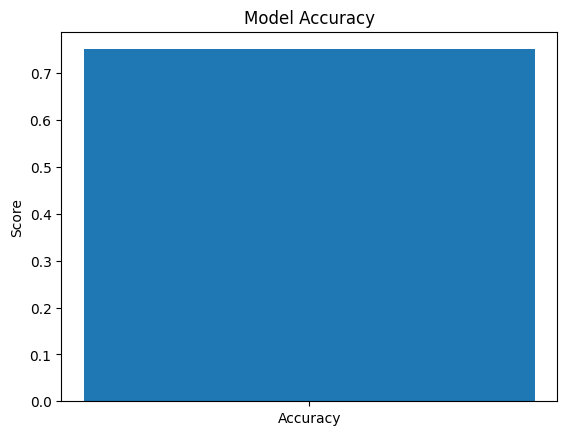

In [34]:
import matplotlib.pyplot as plt

plt.bar(
    ["Accuracy"],
    [accuracy]
)

plt.ylabel("Score")
plt.title("Model Accuracy")

plt.show()

In [35]:
def predict_sentiment(tweet):

    tweet = clean_text(tweet)

    tweet_vector = vectorizer.transform([tweet])

    prediction = model.predict(tweet_vector)

    return prediction[0]

In [36]:
print(
    predict_sentiment(
        "I love this new AI technology"
    )
)

print(
    predict_sentiment(
        "This is the worst product ever"
    )
)

4
0


In [37]:
import joblib

joblib.dump(model, "sentiment_model.pkl")
joblib.dump(vectorizer, "tfidf_vectorizer.pkl")

['tfidf_vectorizer.pkl']